# Common Libraries

In [1]:
import os, sys, shutil
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import xml.etree.ElementTree as ET

# mujoco
if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

In [7]:
sys.path.append("/home/seojin/Seojin_commonTool/Module")

from biomechanics_util import get_mujoco_joints

# Paths

In [21]:
converted_model_path = "/mnt/ext1/seojin/temp/MOBL_ARMS_41_normal/temp_cvt3.xml"
myoarm_model_path = "/home/seojin/biomechanics_tools/myo_sim/arm/myoarm.xml"

# Model

In [22]:
converted_model = mujoco.MjModel.from_xml_path(converted_model_path)
converted_model.opt.gravity = [0,0,0]
converted_model_joint_names = [converted_model.joint(i).name for i in range(converted_model.njnt)]

myoarm_model = mujoco.MjModel.from_xml_path(myoarm_model_path)
myoarm_model.opt.gravity = [0,0,0]
myoarm_model_joint_names = [myoarm_model.joint(i).name for i in range(myoarm_model.njnt)]

In [23]:
dependent_joints, independent_joints = get_mujoco_joints(converted_model_path)

# Pose

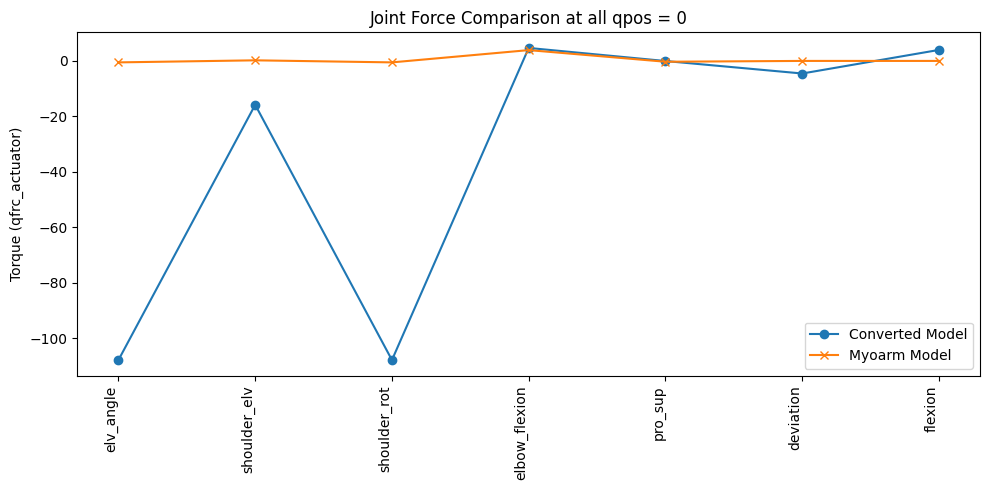

In [25]:
# Converted model qpos
key_id = 0
converted_model_keyframe_qpos = converted_model.key_qpos[key_id].copy()
converted_model_qpos = np.zeros_like(converted_model_keyframe_qpos)

# Intersect
intersect_joints = list(set(converted_model_joint_names).intersection(myoarm_model_joint_names))

# Myoarm qpos
myoarm_qpos = np.zeros(myoarm_model.nq) 
for joint_name in intersect_joints:
    c_adr = converted_model.joint(joint_name).qposadr[0]
    m_adr = myoarm_model.joint(joint_name).qposadr[0]
    myoarm_qpos[m_adr] = converted_model_qpos[c_adr]

def sim_qfrc(model, qpos):
    mj_data = mujoco.MjData(model)
    
    joint_names = [model.joint(i).name for i in range(model.njnt)]
    mj_data.qpos[:] = qpos
    mj_data.ctrl[:] = 0.0
    if model.na > 0:
        mj_data.act[:] = 0.0
    mujoco.mj_forward(model, mj_data)

    """
    target = "INFSP"
    aid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, target)
    model.actuator_biasprm[aid, :] = 0
    mujoco.mj_forward(model, mj_data)
    """
    
    return mj_data.qfrc_actuator.copy()

converted_qfrc = sim_qfrc(converted_model, converted_model_qpos)
myoarm_qfrc = sim_qfrc(myoarm_model, myoarm_qpos)

converted_plot_data = []
myoarm_plot_data = []
for joint_name in independent_joints:
    c_dof_adr = converted_model.joint(joint_name).dofadr[0]
    m_dof_adr = myoarm_model.joint(joint_name).dofadr[0]

    converted_plot_data.append(converted_qfrc[c_dof_adr])
    myoarm_plot_data.append(myoarm_qfrc[m_dof_adr])
    
plt.figure(figsize=(10, 5))
plt.plot(converted_plot_data, label='Converted Model', marker='o')
plt.plot(myoarm_plot_data, label='Myoarm Model', marker='x')
plt.xticks(range(len(independent_joints)), independent_joints, rotation=90, ha='right')
plt.ylabel('Torque (qfrc_actuator)')
plt.title('Joint Force Comparison at all qpos = 0')
plt.legend()
plt.tight_layout()
plt.show()